In [11]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/fraud-project/'
print("Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive connected!


In [12]:
!pip install xgboost imbalanced-learn shap -q
print("Done!")

Done!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [15]:
print("Loading transaction data...")
train = pd.read_csv(DRIVE_PATH + 'train_transaction.csv')
print(f"Transaction shape: {train.shape}")

print("\nLoading identity data...")
identity = pd.read_csv(DRIVE_PATH + 'train_identity.csv')
print(f"Identity shape: {identity.shape}")

Loading transaction data...
Transaction shape: (590540, 394)

Loading identity data...
Identity shape: (144233, 41)


In [16]:
df = train.merge(identity, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
print(f"Total columns: {df.shape[1]}")

Merged shape: (590540, 434)
Total columns: 434


In [17]:
print("SHAPE:", df.shape)
print("\nDATA TYPES:")
print(df.dtypes.value_counts())
print("\nFIRST 5 ROWS:")
df.head()

SHAPE: (590540, 434)

DATA TYPES:
float64    399
object      31
int64        4
Name: count, dtype: int64

FIRST 5 ROWS:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Legit: 569,877  (96.50%)
Fraud: 20,663  (3.50%)


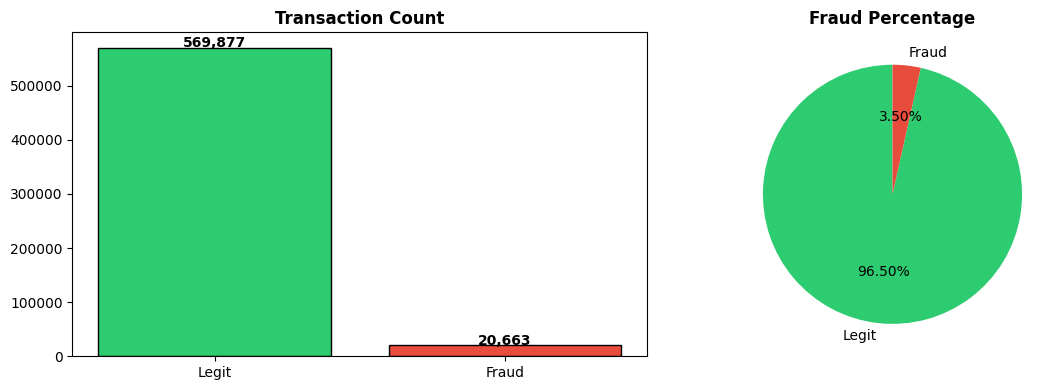

In [18]:
# Fraud Distribution
count = df['isFraud'].value_counts()
pct   = df['isFraud'].value_counts(normalize=True) * 100

print(f"Legit: {count[0]:,}  ({pct[0]:.2f}%)")
print(f"Fraud: {count[1]:,}  ({pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legit','Fraud'], [count[0], count[1]],
            color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Transaction Count', fontweight='bold')
for i, v in enumerate([count[0], count[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([count[0], count[1]], labels=['Legit','Fraud'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Fraud Percentage', fontweight='bold')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Missing Values
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).sort_values('Missing %', ascending=False)

print("Top 20 columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0].head(20))

Top 20 columns with missing values:
       Missing Count  Missing %
id_24         585793  99.196159
id_25         585408  99.130965
id_07         585385  99.127070
id_08         585385  99.127070
id_21         585381  99.126393
id_26         585377  99.125715
id_27         585371  99.124699
id_23         585371  99.124699
id_22         585371  99.124699
dist2         552913  93.628374
D7            551623  93.409930
id_18         545427  92.360721
D13           528588  89.509263
D14           528353  89.469469
D12           525823  89.041047
id_04         524216  88.768923
id_03         524216  88.768923
D6            517353  87.606767
id_33         517251  87.589494
id_09         515614  87.312290


LEGIT — Avg: $134.51  Max: $31937.39
FRAUD — Avg: $149.24  Max: $5191.00


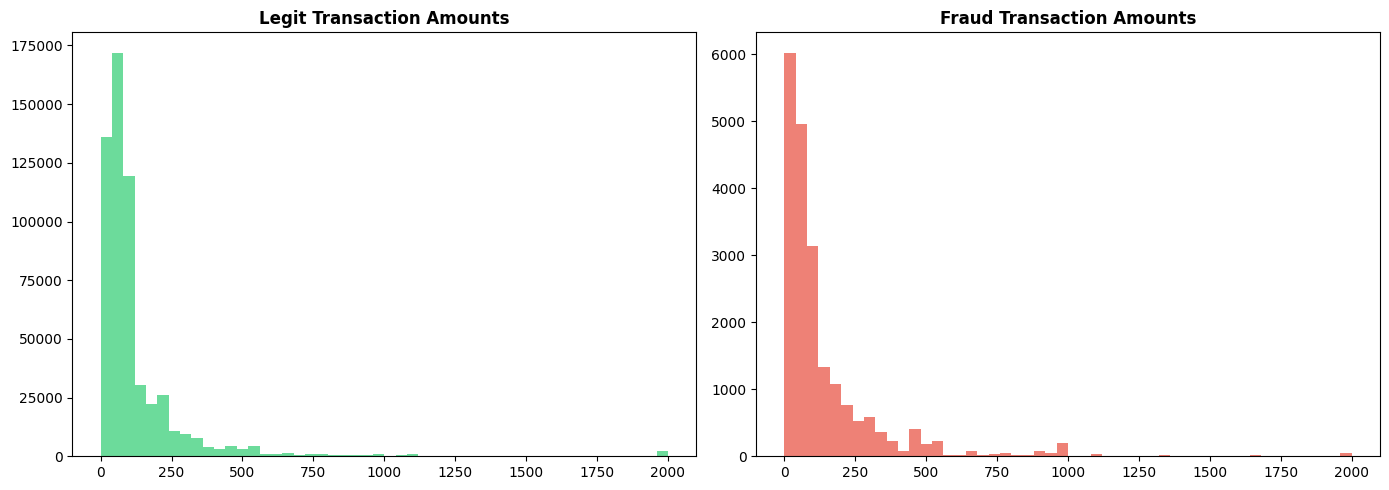

In [20]:
# Transaction Amount
legit = df[df['isFraud'] == 0]['TransactionAmt']
fraud = df[df['isFraud'] == 1]['TransactionAmt']

print(f"LEGIT — Avg: ${legit.mean():.2f}  Max: ${legit.max():.2f}")
print(f"FRAUD — Avg: ${fraud.mean():.2f}  Max: ${fraud.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(legit.clip(upper=2000), bins=50, color='#2ecc71', alpha=0.7)
axes[0].set_title('Legit Transaction Amounts', fontweight='bold')
axes[1].hist(fraud.clip(upper=2000), bins=50, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts', fontweight='bold')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

           Fraud Count   Total  Fraud Rate
ProductCD                                 
C                 8008   68519   11.687269
S                  686   11628    5.899553
H                 1574   33024    4.766231
R                 1426   37699    3.782594
W                 8969  439670    2.039939


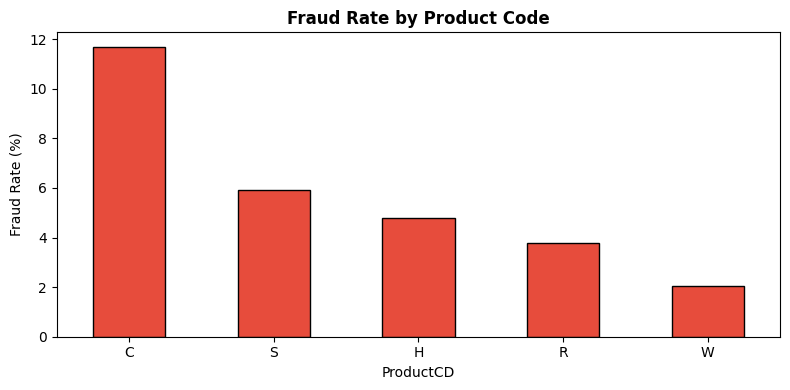

In [21]:
# Product Code
product_fraud = df.groupby('ProductCD')['isFraud'].agg(['sum','count','mean'])
product_fraud.columns = ['Fraud Count', 'Total', 'Fraud Rate']
product_fraud['Fraud Rate'] = product_fraud['Fraud Rate'] * 100
print(product_fraud.sort_values('Fraud Rate', ascending=False))

product_fraud['Fraud Rate'].sort_values(ascending=False).plot(
    kind='bar', color='#e74c3c', edgecolor='black', figsize=(8, 4))
plt.title('Fraud Rate by Product Code', fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'product_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

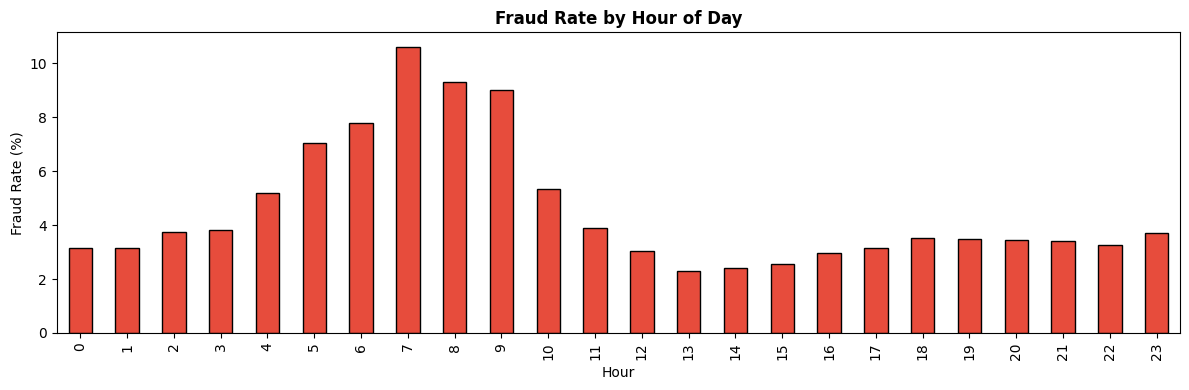

Peak fraud hour: 7:00  (10.61%)


In [22]:
# Hour Analysis
df['hour'] = (df['TransactionDT'] // 3600) % 24
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100

hourly_fraud.plot(kind='bar', color='#e74c3c', edgecolor='black', figsize=(12, 4))
plt.title('Fraud Rate by Hour of Day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'hourly_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak fraud hour: {hourly_fraud.idxmax()}:00  ({hourly_fraud.max():.2f}%)")

In [23]:
# EDA Summary
print("="*50)
print("EDA COMPLETE — KEY FINDINGS")
print("="*50)
print(f"Total transactions : {len(df):,}")
print(f"Fraud cases        : {df['isFraud'].sum():,}  ({df['isFraud'].mean()*100:.2f}%)")
print(f"Fraud avg amount   : ${df[df['isFraud']==1]['TransactionAmt'].mean():.2f}")
print(f"Legit avg amount   : ${df[df['isFraud']==0]['TransactionAmt'].mean():.2f}")
print(f"Peak fraud hour    : {hourly_fraud.idxmax()}:00")
print("="*50)
print("Move to Notebook 2 — Preprocessing")

EDA COMPLETE — KEY FINDINGS
Total transactions : 590,540
Fraud cases        : 20,663  (3.50%)
Fraud avg amount   : $149.24
Legit avg amount   : $134.51
Peak fraud hour    : 7:00
Move to Notebook 2 — Preprocessing
